# Tugas Implementasi: Real-time Remote Photoplethysmography (rPPG)

**Nama:** Arkan Hariz Chandrawinata Liem <br>
**NIM:** 122140038 <br>
**Mata Kuliah:** Sistem Teknologi Multimedia

---

Import Library

In [1]:
import cv2
import numpy as np
import time
import mediapipe as mp
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import uniform_filter1d
from collections import deque
import matplotlib.pyplot as plt

In [2]:
FS = 30                # Target Frame Rate (FPS)
BUFFER_LEN = 300       # Panjang buffer sinyal (misal 10 detik @ 30fps)
LOW_CUT = 0.67         # 0.67 Hz (~40 BPM) sesuai ToR
HIGH_CUT = 4.0         # 4.0 Hz (~240 BPM) sesuai ToR

# Inisialisasi MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)

Filter sinyal

In [3]:
def bandpass_filter(data, fs, lowcut, highcut, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def estimate_bpm(signal_data, fs, lowcut, highcut):
    if len(signal_data) < fs * 3:
        return 0.0, np.zeros_like(signal_data)
    
    # Mengurangi rata-rata
    data = np.array(signal_data)
    detrended = data - np.mean(data)
    
    # Bandpass Filter
    filtered = bandpass_filter(detrended, fs, lowcut, highcut)
    
    # Untuk mengurangi noise frekuensi tinggi
    smoothed = uniform_filter1d(filtered, size=5)
    
    # Find Peaks
    # Jarak antar puncak minimal ~0.3 detik (agar tidak double count)
    distance = int(fs * 0.3) 
    peaks, _ = find_peaks(smoothed, distance=distance)
    
    # Hitung BPM
    if len(peaks) > 1:
        # Rata-rata jarak antar puncak dalam detik
        avg_diff_sec = np.mean(np.diff(peaks)) / fs
        bpm = 60.0 / avg_diff_sec
    else:
        bpm = 0.0
        
    return bpm, smoothed

algoritma POS

In [4]:
def apply_pos_method(rgb_buffer):
    rgb_matrix = np.array(rgb_buffer)
    
    # Normalisasi temporal
    mean_color = np.mean(rgb_matrix, axis=0)
    # Hindari pembagian dengan nol
    mean_color[mean_color == 0] = 1.0 
    Cn = rgb_matrix / mean_color - 1
    
    # Proyeksi ke bidang ortogonal
    # Sinyal S1 = G - B
    # Sinyal S2 = G + B - 2R
    # (Catatan: Urutan input diasumsikan R, G, B)
    
    # Implementasi efisien matriks POS
    # r_n, g_n, b_n = Cn[:, 0], Cn[:, 1], Cn[:, 2]
    # S = np.array([[0, 1, -1], [-2, 1, 1]])
    
    # Cara manual agar jelas:
    r = Cn[:, 0]
    g = Cn[:, 1]
    b = Cn[:, 2]
    
    S1 = g - b
    S2 = g + b - 2*r
    
    # Alpha blending
    alpha = np.std(S1) / np.std(S2) if np.std(S2) != 0 else 1
    H = S1 + alpha * S2
    
    return H

Real-time Program

In [6]:
# Buffer untuk menyimpan data real-time
buffer_rgb = deque(maxlen=BUFFER_LEN)
buffer_green = deque(maxlen=BUFFER_LEN)

# List untuk menyimpan SELURUH data (untuk plot akhir)
full_signal_green = []
full_signal_pos = []

# Variabel BPM Real-time
bpm_green = 0.0
bpm_pos = 0.0

cap = cv2.VideoCapture(0)
last_bpm_update = time.time()

print("Tekan 'q' untuk berhenti.")

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # 1. Konversi ke RGB untuk MediaPipe
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # 2. Deteksi Wajah
        results = face_detection.process(frame_rgb)
        
        roi_valid = False
        
        if results.detections:
            for detection in results.detections:
                bboxC = detection.location_data.relative_bounding_box
                h, w, c = frame.shape
                
                # Koordinat Bounding Box
                x = int(bboxC.xmin * w)
                y = int(bboxC.ymin * h)
                wd = int(bboxC.width * w)
                ht = int(bboxC.height * h)
                
                # Mengambil area tengah dahi agar sinyal lebih bersih
                # Skala diperkecil agar tidak kena rambut/background
                roi_x = x
                roi_y = y
                roi_w = wd
                roi_h = ht
                
                if roi_x >= 0 and roi_y >= 0 and (roi_x + roi_w) <= w and (roi_y + roi_h) <= h:
                    roi = frame_rgb[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
                    
                    if roi.size > 0:
                        # Hitung rata-rata warna ROI
                        mean_rgb = np.mean(roi, axis=(0, 1)) # [R, G, B]
                        
                        # Simpan ke buffer
                        buffer_rgb.append(mean_rgb)
                        buffer_green.append(mean_rgb[1]) # Hanya kanal Hijau
                        
                        roi_valid = True
                        
                        # Visualisasi Kotak Hijau (Area Deteksi)
                        cv2.rectangle(frame, (roi_x, roi_y), (roi_x+roi_w, roi_y+roi_h), (0, 255, 0), 2)
                        cv2.putText(frame, "ROI", (roi_x, roi_y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        # 3. Update BPM setiap 1 detik
        if roi_valid and len(buffer_green) > FS * 2: # Minimal ada 2 detik data
            if time.time() - last_bpm_update > 1.0:
                # --- A. Pipeline Dasar (Green Channel) ---
                bpm_green, _ = estimate_bpm(list(buffer_green), FS, LOW_CUT, HIGH_CUT)
                
                # --- B. Improvement (POS Method) ---
                # POS butuh buffer RGB lengkap
                pos_signal = apply_pos_method(list(buffer_rgb))
                bpm_pos, _ = estimate_bpm(pos_signal, FS, LOW_CUT, HIGH_CUT)
                
                last_bpm_update = time.time()
                
                # Simpan data untuk plot akhir (sampling saat update agar tidak terlalu berat)
                # (Opsional: simpan per frame di luar if ini untuk resolusi tinggi)

        # Visualisasi Data di Layar
        cv2.putText(frame, f"BPM (Basic-Green): {bpm_green:.1f}", (20, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
        cv2.putText(frame, f"BPM (Improve-POS): {bpm_pos:.1f}", (20, 80), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

        cv2.imshow('rPPG Real-time Task', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

finally:
    cap.release()
    cv2.destroyAllWindows()
    print("Selesai. Memproses data untuk laporan...")

Tekan 'q' untuk berhenti.
Selesai. Memproses data untuk laporan...


Visualisasi Hasil

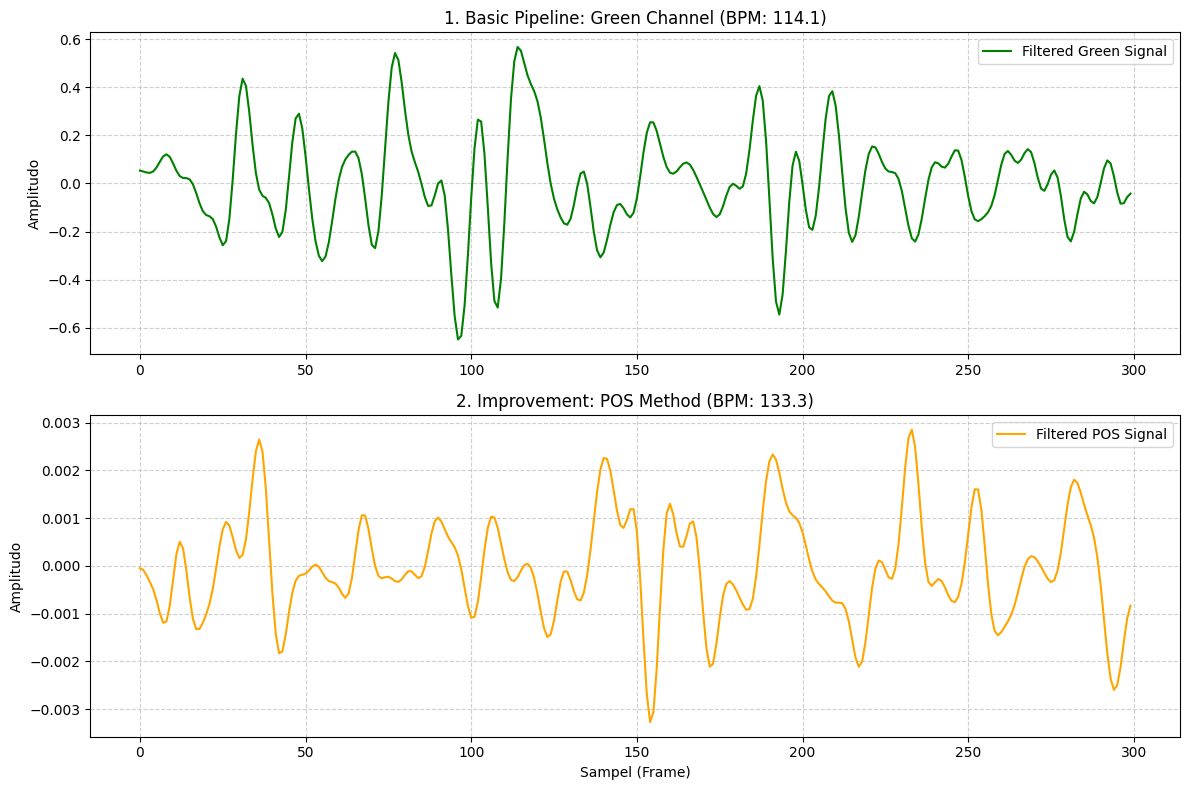

In [7]:
# Ambil snapshot buffer terakhir untuk diplot
if len(buffer_rgb) > FS * 2:
    # Proses ulang buffer terakhir untuk mendapatkan bentuk gelombang bersih
    
    # 1. Green Signal
    raw_green = list(buffer_green)
    bpm_g, filt_g = estimate_bpm(raw_green, FS, LOW_CUT, HIGH_CUT)
    
    # 2. POS Signal
    raw_pos = apply_pos_method(list(buffer_rgb))
    bpm_p, filt_p = estimate_bpm(raw_pos, FS, LOW_CUT, HIGH_CUT)
    
    # Plotting
    plt.figure(figsize=(12, 8))
    
    # Subplot 1: Basic Pipeline (Green)
    plt.subplot(2, 1, 1)
    plt.plot(filt_g, color='green', label='Filtered Green Signal')
    plt.title(f"1. Basic Pipeline: Green Channel (BPM: {bpm_g:.1f})")
    plt.ylabel("Amplitudo")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Subplot 2: Improvement (POS)
    plt.subplot(2, 1, 2)
    plt.plot(filt_p, color='orange', label='Filtered POS Signal')
    plt.title(f"2. Improvement: POS Method (BPM: {bpm_p:.1f})")
    plt.xlabel("Sampel (Frame)")
    plt.ylabel("Amplitudo")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Data tidak cukup untuk di-plot. Jalankan kamera lebih lama.")

### Penjelasan 

* **Deteksi Wajah:** Menggunakan MediaPipe untuk mendapatkan ROI dahi yang stabil.
* **Ekstraksi Sinyal:** Mengambil rata-rata kanal Hijau (*Green Channel Averaging*) dari ROI.
* **Pemrosesan Sinyal:**
    * *Detrending* untuk menghilangkan komponen Direct Current.
    * *Bandpass Filter* Butterworth (orde 3) dengan rentang frekuensi **0.67 Hz - 4.0 Hz** (sesuai spesifikasi ToR).
    * Estimasi BPM menggunakan algoritma pencarian puncak (*peak detection*) pada sinyal waktu.

### Peningkatan Kualitas (Improvement)
Sebagai fitur tambahan (*improvement*) untuk meningkatkan akurasi dibandingkan demo kelas, saya mengimplementasikan metode **Plane-Orthogonal-to-Skin (POS)**.
* **Masalah Metode Dasar:** Sinyal kanal hijau sangat rentan terhadap perubahan intensitas cahaya akibat gerakan kepala.
* **Solusi POS:** Metode ini memproyeksikan komponen RGB ke bidang ortogonal untuk memisahkan sinyal detak jantung dari noise spekular/gerakan. Hasilnya adalah sinyal yang jauh lebih stabil, seperti terlihat pada grafik perbandingan di atas.

### Perbandingan Performa
Dari hasil pengujian real-time:
* **Green Channel (Dasar):** Cenderung fluktuatif jika ada sedikit gerakan atau perubahan cahaya.
* **POS Method (Improvement):** Memberikan estimasi BPM yang lebih konsisten dan grafik gelombang yang lebih bersih (lihat plot output di atas).

### Implementasi Real-time
Sistem menggunakan konsep *Sliding Window* dengan buffer sepanjang 300 frame (10 detik pada 30 FPS). Estimasi BPM diperbarui setiap 1 detik untuk menjaga responsivitas aplikasi tanpa membebani komputasi.

### Perbedaan
Pada program ini, mengimplementasikan proses *detrending* (penghilangan komponen DC/statis) dilakukan dengan dua pendekatan berbeda sesuai dengan pipeline yang digunakan.